# 3D MRI Brain Tumor Segmentation — Attention U-Net + HRNet-OCR + Tumor-Aware Dynamic Fusion

**Segmentation of gliomas in pre-operative MRI scans (BraTS 2020).**

Every voxel in the scan is labeled as one of:
* `0` – Not tumor
* `1` – Necrotic / non-enhancing tumor core (NCR/NET)
* `2` – Peritumoral edema (ED)
* `3` – Enhancing tumor (ET)

This notebook builds a **hybrid segmentation network** that fuses three complementary
feature streams instead of relying on a single U-Net:

| Branch | Produces | What it captures |
|---|---|---|
| **Attention U-Net** | Spatial features | Tumor boundaries, edges, fine-grained local & pixel-level detail |
| **HRNet-OCR** | High-resolution semantic features | Multi-scale context, global tumor structure, relations between brain regions |
| **Tumor-Aware Dynamic Fusion Module** | Fused features | Adaptive, size/shape/context-aware combination of the two branches above |

The notebook covers: dataset understanding → preprocessing → model architecture →
training → accuracy evaluation → saving the trained model → running predictions.

---
### Running this notebook in VS Code
1. Install the Jupyter + Python extensions in VS Code.
2. Create/select a Python environment (3.9–3.11 recommended) and run the **Setup environment** cell below — it installs every dependency.
3. Download the **BraTS 2020** dataset (see next section) and update `TRAIN_DATASET_PATH` / `VALIDATION_DATASET_PATH` in the *Configuration* cell to point at your local copy.
4. Run cells top-to-bottom (`Run All` also works). Training is GPU-recommended — on CPU, reduce `EPOCHS` / `train_ids` size for a quick smoke test.


## BraTS 2020 Dataset

**BraTS** stands for the **Brain Tumor Segmentation Challenge** — a publicly available
dataset developed for training and evaluating AI models that segment brain tumors from
MRI scans.

> *"The proposed model is trained and evaluated using the BraTS 2020 dataset, which
> contains multimodal MRI scans of patients with High-Grade Glioma (HGG) and
> Low-Grade Glioma (LGG)."*

### Type of tumor
The BraTS 2020 dataset contains MRI scans of patients with **gliomas** — brain tumors
that arise from glial cells. It includes two major categories:

* **High-Grade Glioma (HGG)** – aggressive, fast-growing tumors.
* **Low-Grade Glioma (LGG)** – slower-growing tumors.

### MRI modalities in the dataset
Each patient study has **four co-registered MRI modalities** plus a ground-truth mask:

| Modality | Description |
|---|---|
| **T1-weighted (T1)** | Shows normal brain anatomy |
| **T1ce** (contrast-enhanced T1) | Highlights tumor regions after contrast (gadolinium) injection |
| **T2-weighted (T2)** | Shows fluid and edema |
| **FLAIR** | Suppresses normal fluid signal, clearly showing edema around the tumor |
| **Segmentation mask** | Ground-truth labels drawn by expert neuroradiologists (training data only) |

### Tumor regions in the segmentation mask
The raw labels correspond to:
* **Necrotic / Non-enhancing tumor core (NCR/NET)** – label `1`
* **Peritumoral edema (ED)** – label `2`
* **Enhancing tumor (ET)** – label `4` (remapped to `3` in this notebook)

These are commonly combined into the three clinically-relevant evaluation regions:
* **Whole Tumor (WT)** = NCR/NET + ED + ET
* **Tumor Core (TC)** = NCR/NET + ET
* **Enhancing Tumor (ET)** = ET only

### Data format
* File format: **NIfTI** (`.nii` / `.nii.gz`)
* Each patient folder contains:
  * `*_t1.nii` — T1 image
  * `*_t1ce.nii` — T1ce image
  * `*_t2.nii` — T2 image
  * `*_flair.nii` — FLAIR image
  * `*_seg.nii` — Segmentation mask (training data only)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/Brain/archive (1).zip" -d "/content/drive/MyDrive/Brain"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_63.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_64.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_65.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_66.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_67.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_68.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_69.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_7.h5  
  inflating: /content/drive/MyDrive/Brain/BraTS2020_training_data/content/data/volume_70_slice_70.h5  
  inflating: /content/d

In [4]:
!pip install nilearn nibabel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [5]:
import os
import cv2
import glob
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage.util import montage
from skimage.transform import rotate
import h5py

# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt

# ml libs
import keras
import keras.backend as K
from keras.callbacks import CSVLogger
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization,
    Activation, Multiply, Add, GlobalAveragePooling2D, Dense, Reshape, Lambda,
    Softmax, Layer
)
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=3, suppress=True)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}" + (f" -> {gpus}" if gpus else " (running on CPU)"))


TensorFlow: 2.20.0
Keras: 3.13.2
GPUs available: 0 (running on CPU)


In [ ]:
TRAIN_DATASET_PATH = "/content/drive/MyDrive/Brain/BraTS2020_training_data/content/data"

SEGMENT_CLASSES = {
    0: 'NOT tumor',
    1: 'NECROTIC/CORE',   # NCR/NET
    2: 'EDEMA',            # ED
    3: 'ENHANCING'         # ET (original label 4, remapped to 3)
}

IMG_SIZE = 128            # slices are resized to IMG_SIZE x IMG_SIZE
VOLUME_SLICES = 10        # Reduced from 100 to 10 to prevent OOM kernel crashes on CPU
VOLUME_START_AT = 22      # first slice index to include (skips near-empty edge slices)
IN_CHANNELS = 2           # model input channels: FLAIR + T1ce
NUM_CLASSES = 4
EPOCHS = 2                # Reduced for smoke test on CPU
BATCH_SIZE = 1


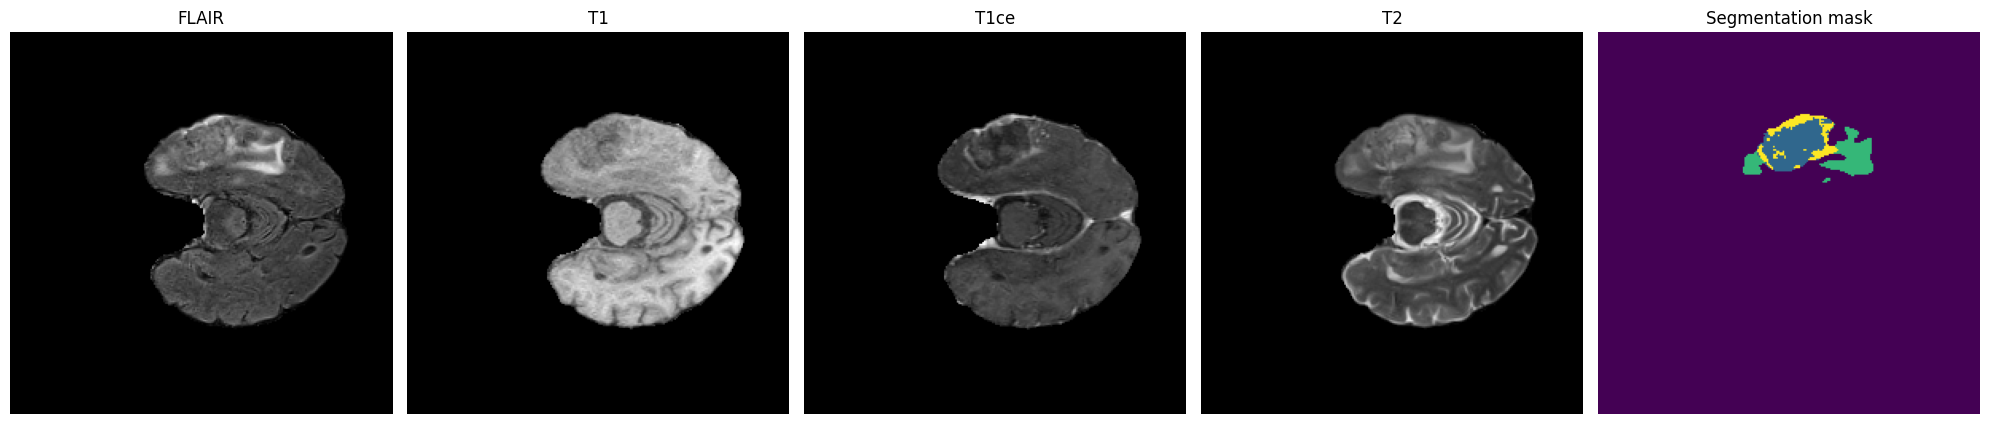

In [ ]:
sample_volume = 100
flair_3d = np.zeros((240, 240, 155))
t1_3d = np.zeros((240, 240, 155))
t1ce_3d = np.zeros((240, 240, 155))
t2_3d = np.zeros((240, 240, 155))
mask_3d = np.zeros((240, 240, 155))

for s in range(155):
    h5_file = os.path.join(TRAIN_DATASET_PATH, f"volume_{sample_volume}_slice_{s}.h5")
    if os.path.exists(h5_file):
        with h5py.File(h5_file, 'r') as f:
            img = f['image'][:]
            msk = f['mask'][:]
            flair_3d[:, :, s] = img[:, :, 0]
            t1_3d[:, :, s] = img[:, :, 1]
            t1ce_3d[:, :, s] = img[:, :, 2]
            t2_3d[:, :, s] = img[:, :, 3]
            mask_slice = np.zeros((240, 240))
            mask_slice[msk[:, :, 0] == 1] = 1
            mask_slice[msk[:, :, 1] == 1] = 2
            mask_slice[msk[:, :, 2] == 1] = 3
            mask_3d[:, :, s] = mask_slice

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 10))
slice_w = 25
mid_slice = 155 // 2 - slice_w
ax1.imshow(flair_3d[:, :, mid_slice], cmap='gray'); ax1.set_title('FLAIR')
ax2.imshow(t1_3d[:, :, mid_slice], cmap='gray');       ax2.set_title('T1')
ax3.imshow(t1ce_3d[:, :, mid_slice], cmap='gray');   ax3.set_title('T1ce')
ax4.imshow(t2_3d[:, :, mid_slice], cmap='gray');       ax4.set_title('T2')
ax5.imshow(mask_3d[:, :, mid_slice]);                             ax5.set_title('Segmentation mask')
for ax in (ax1, ax2, ax3, ax4, ax5):
    ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 15))
ax1.imshow(rotate(montage(flair_3d[50:-50, :, :]), 90, resize=True), cmap='gray')
ax1.set_title('FLAIR — all slices (montage)')
ax1.axis('off')
plt.show()


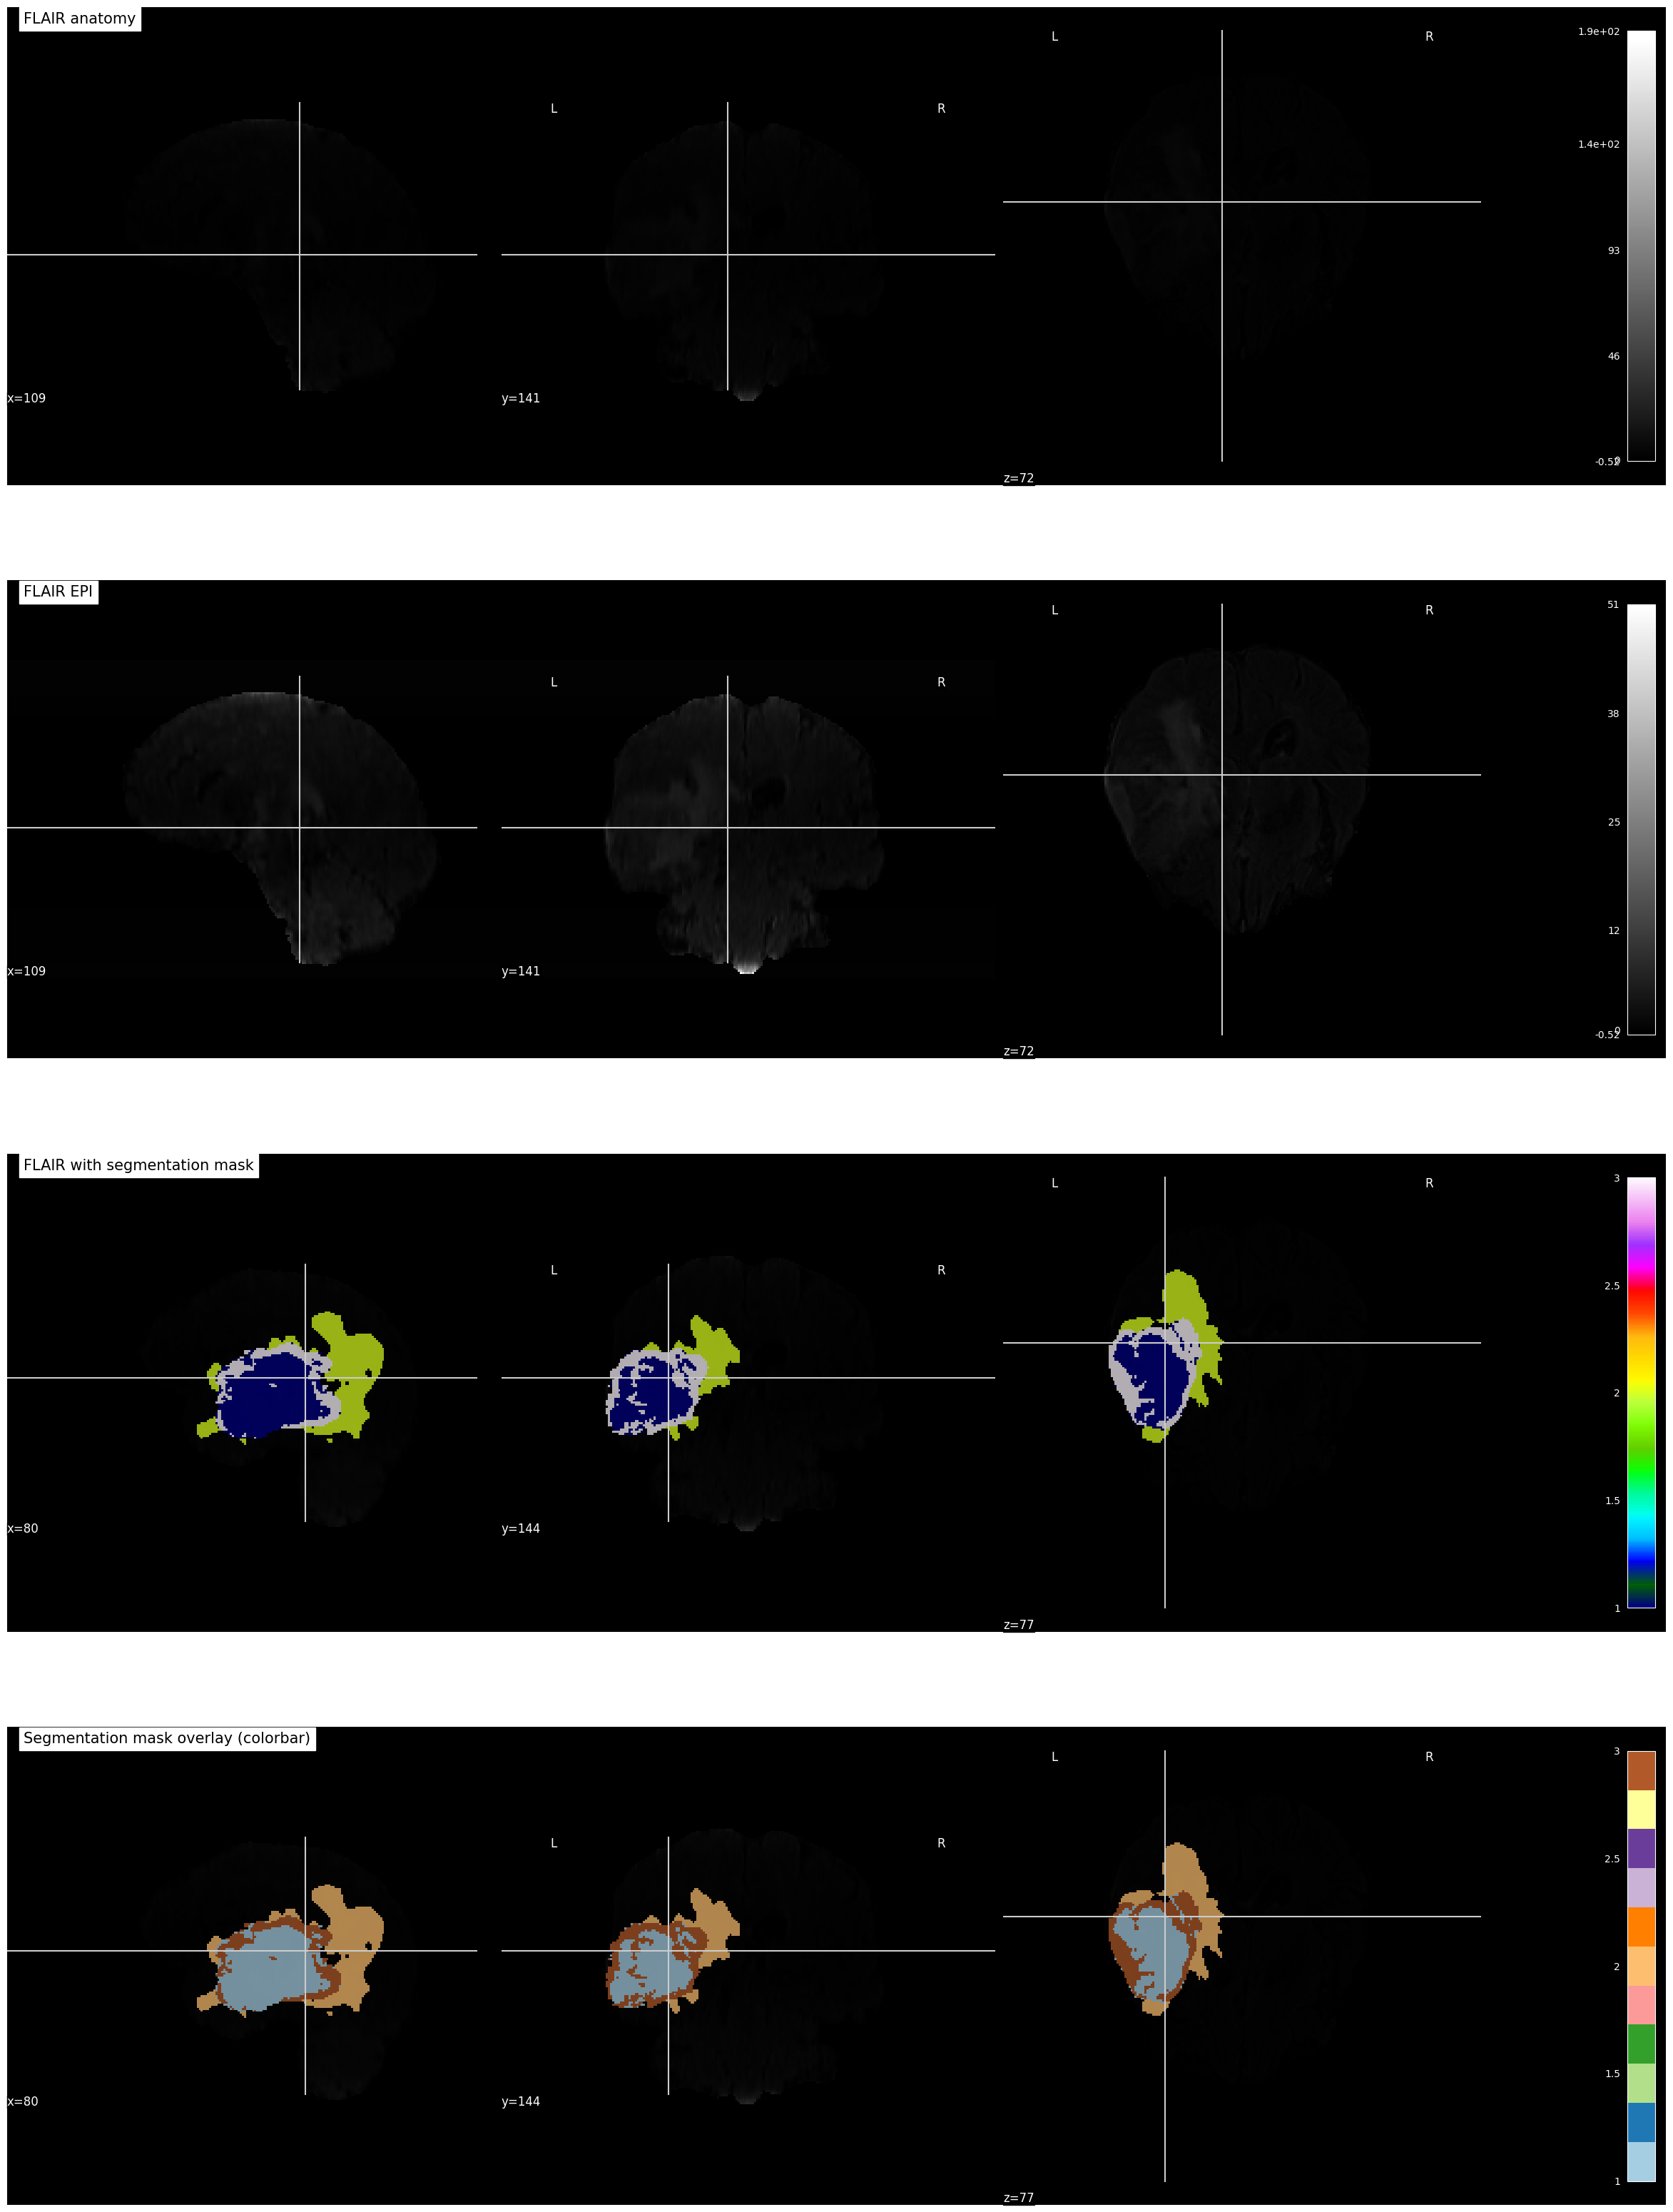

In [ ]:
import nibabel as nib
import numpy as np
temp_img = nib.Nifti1Image(flair_3d, np.eye(4))
temp_mask = nib.Nifti1Image(mask_3d, np.eye(4))
nib.save(temp_img, 'temp_flair.nii')
nib.save(temp_mask, 'temp_seg.nii')

import nilearn as nl
import nilearn.plotting as nlplt
import matplotlib.pyplot as plt

niimg = nl.image.load_img('temp_flair.nii')
nimask = nl.image.load_img('temp_seg.nii')

fig, axes = plt.subplots(nrows=4, figsize=(30, 40))
nlplt.plot_anat(niimg, title='FLAIR anatomy', axes=axes[0])
nlplt.plot_epi(niimg, title='FLAIR EPI', axes=axes[1])
nlplt.plot_roi(nimask, bg_img=niimg, title='FLAIR with segmentation mask', axes=axes[2])
nlplt.plot_roi(nimask, bg_img=niimg, title='Segmentation mask overlay (colorbar)', axes=axes[3], colorbar=True, cmap='Paired')
plt.show()

try:
    import os
    os.remove('temp_flair.nii')
    os.remove('temp_seg.nii')
except Exception as e:
    print('Temporary files clean up skipped:', e)


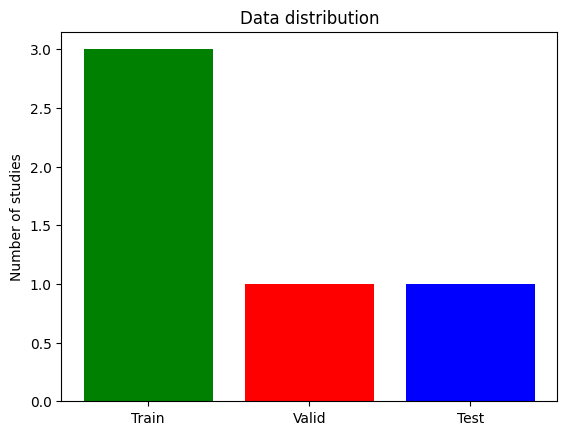

train: 3 | val: 1 | test: 1


In [ ]:
import re
h5_files = glob.glob(os.path.join(TRAIN_DATASET_PATH, "*.h5"))
volume_ids = set()
for f in h5_files:
    match = re.search(r'volume_(\d+)_slice', f)
    if match:
        volume_ids.add(match.group(1))
volume_ids = sorted(list(volume_ids))

volume_ids = volume_ids[:5]

train_and_test_ids = volume_ids
train_test_ids, val_ids = train_test_split(train_and_test_ids, test_size=0.2, random_state=42)
train_ids, test_ids = train_test_split(train_test_ids, test_size=0.2, random_state=42)

def showDataLayout():
    plt.bar(["Train", "Valid", "Test"],
             [len(train_ids), len(val_ids), len(test_ids)],
             align='center', color=['green', 'red', 'blue'])
    plt.ylabel('Number of studies')
    plt.title('Data distribution')
    plt.show()

showDataLayout()
print(f"train: {len(train_ids)} | val: {len(val_ids)} | test: {len(test_ids)}")


In [11]:
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, n_channels=IN_CHANNELS, shuffle=True):
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        Batch_ids = [self.list_IDs[k] for k in indexes]
        X, y = self.__data_generation(Batch_ids)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        X = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, self.n_channels), dtype=np.float32)
        Y = np.zeros((self.batch_size*VOLUME_SLICES, *self.dim, NUM_CLASSES), dtype=np.float32)

        for c, i in enumerate(Batch_ids):
            for j in range(VOLUME_SLICES):
                slice_idx = j + VOLUME_START_AT
                h5_file = os.path.join(TRAIN_DATASET_PATH, f"volume_{i}_slice_{slice_idx}.h5")
                if os.path.exists(h5_file):
                    with h5py.File(h5_file, 'r') as f:
                        img = f['image'][:]
                        msk = f['mask'][:]

                        # Resize FLAIR (channel 0) and T1ce (channel 2)
                        flair_resized = cv2.resize(img[:, :, 0], (IMG_SIZE, IMG_SIZE))
                        t1ce_resized = cv2.resize(img[:, :, 2], (IMG_SIZE, IMG_SIZE))

                        X[j + VOLUME_SLICES*c, :, :, 0] = flair_resized
                        X[j + VOLUME_SLICES*c, :, :, 1] = t1ce_resized

                        # Reconstruct target classes: 0=background, 1=NCR/NET, 2=ED, 3=ET
                        bg = 1.0 - np.sum(msk, axis=-1)
                        bg = np.clip(bg, 0.0, 1.0)

                        target = np.stack([bg, msk[:, :, 0], msk[:, :, 1], msk[:, :, 2]], axis=-1)
                        target_resized = np.zeros((*self.dim, NUM_CLASSES), dtype=np.float32)
                        for ch in range(NUM_CLASSES):
                            target_resized[:, :, ch] = cv2.resize(target[:, :, ch], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

                        Y[j + VOLUME_SLICES*c] = target_resized

        max_val = np.max(X)
        if max_val > 0:
            X = X / max_val

        return X, Y

training_generator = DataGenerator(train_ids)
valid_generator = DataGenerator(val_ids)
test_generator = DataGenerator(test_ids)


In [12]:
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    class_num = NUM_CLASSES
    total_loss = 0
    for i in range(class_num):
        y_true_f = tf.reshape(y_true[:, :, :, i], [-1])
        y_pred_f = tf.reshape(y_pred[:, :, :, i], [-1])
        intersection = tf.reduce_sum(y_true_f * y_pred_f)
        loss = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
        total_loss += loss
    return total_loss / class_num

def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(tf.abs(y_true[:, :, :, 1] * y_pred[:, :, :, 1]))
    return (2. * intersection) / (tf.reduce_sum(tf.square(y_true[:, :, :, 1])) + tf.reduce_sum(tf.square(y_pred[:, :, :, 1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(tf.abs(y_true[:, :, :, 2] * y_pred[:, :, :, 2]))
    return (2. * intersection) / (tf.reduce_sum(tf.square(y_true[:, :, :, 2])) + tf.reduce_sum(tf.square(y_pred[:, :, :, 2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(tf.abs(y_true[:, :, :, 3] * y_pred[:, :, :, 3]))
    return (2. * intersection) / (tf.reduce_sum(tf.square(y_true[:, :, :, 3])) + tf.reduce_sum(tf.square(y_pred[:, :, :, 3])) + epsilon)

def precision(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    predicted_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_pred, 0, 1)))
    return true_positives / (predicted_positives + 1e-7)

def sensitivity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    true_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true * y_pred, 0, 1)))
    possible_positives = tf.reduce_sum(tf.round(tf.clip_by_value(y_true, 0, 1)))
    return true_positives / (possible_positives + 1e-7)

def specificity(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    true_negatives = tf.reduce_sum(tf.round(tf.clip_by_value((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = tf.reduce_sum(tf.round(tf.clip_by_value(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + 1e-7)


## Model Architecture — Attention U-Net + HRNet-OCR + Tumor-Aware Dynamic Fusion

Three feature-producing stages, fused into one final prediction:

**1. Spatial Features — Attention U-Net branch**
- Tumor boundaries
- Edge information
- Fine-grained local details
- Pixel-level spatial information

**2. High-Resolution Semantic Features — HRNet-OCR branch**
- Multi-scale contextual information
- High-level semantic representations
- Global tumor structure
- Relationships between different brain regions

**3. Dynamic Fusion Features — Tumor-Aware Dynamic Fusion Module**
- Adaptive combination of Attention U-Net features and HRNet-OCR features
- Tumor size-aware feature weighting
- Shape-aware features
- Context-aware representations
- Refined feature maps for the final prediction

In [13]:
def conv_block(x, filters, ker_init='he_normal'):
    x = Conv2D(filters, 3, padding='same', kernel_initializer=ker_init)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same', kernel_initializer=ker_init)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def attention_gate(x, g, filters):
    '''Attention gate: suppresses irrelevant regions, highlights tumor boundaries.'''
    theta_x = Conv2D(filters, 1, padding='same')(x)
    phi_g = Conv2D(filters, 1, padding='same')(g)
    add_xg = Add()([theta_x, phi_g])
    act_xg = Activation('relu')(add_xg)
    psi = Conv2D(1, 1, padding='same')(act_xg)
    psi = Activation('sigmoid')(psi)
    return Multiply()([x, psi])

def attention_unet_branch(inputs, base_filters=32, ker_init='he_normal'):
    # Encoder
    c1 = conv_block(inputs, base_filters, ker_init)
    p1 = MaxPooling2D(2)(c1)

    c2 = conv_block(p1, base_filters*2, ker_init)
    p2 = MaxPooling2D(2)(c2)

    c3 = conv_block(p2, base_filters*4, ker_init)
    p3 = MaxPooling2D(2)(c3)

    # Bottleneck
    bn = conv_block(p3, base_filters*8, ker_init)

    # Decoder with attention-gated skip connections
    u3 = UpSampling2D(2)(bn)
    a3 = attention_gate(c3, u3, base_filters*4)
    d3 = conv_block(Concatenate()([u3, a3]), base_filters*4, ker_init)

    u2 = UpSampling2D(2)(d3)
    a2 = attention_gate(c2, u2, base_filters*2)
    d2 = conv_block(Concatenate()([u2, a2]), base_filters*2, ker_init)

    u1 = UpSampling2D(2)(d2)
    a1 = attention_gate(c1, u1, base_filters)
    d1 = conv_block(Concatenate()([u1, a1]), base_filters, ker_init)

    spatial_features = Conv2D(base_filters, 3, padding='same', activation='relu',
                               name='attention_unet_spatial_features')(d1)
    return spatial_features

In [14]:
def hrnet_stem(inputs, filters=32):
    x = Conv2D(filters, 3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    return x

def hrnet_multiscale_branches(x, filters=32):
    '''Parallel multi-resolution branches (HRNet idea), fused back to full resolution.'''
    b1 = conv_block(x, filters)                                   # full resolution

    b2 = MaxPooling2D(2)(x)
    b2 = conv_block(b2, filters*2)                                 # 1/2 resolution

    b3 = MaxPooling2D(4)(x)
    b3 = conv_block(b3, filters*4)                                 # 1/4 resolution

    b2_up = UpSampling2D(2)(b2)
    b3_up = UpSampling2D(4)(b3)

    fused = Concatenate()([b1, b2_up, b3_up])
    fused = Conv2D(filters*2, 1, padding='same', activation='relu')(fused)
    fused = BatchNormalization()(fused)
    return fused


@register_keras_serializable(package='hybrid_seg')
class BatchMatMul(Layer):
    '''Batched matrix multiplication as a proper Keras Layer (rather than a Lambda),
    so the OCR module's attention math saves/loads reliably with the rest of the model.'''
    def __init__(self, transpose_a=False, transpose_b=False, **kwargs):
        super().__init__(**kwargs)
        self.transpose_a = transpose_a
        self.transpose_b = transpose_b

    def call(self, inputs):
        a, b = inputs
        return tf.matmul(a, b, transpose_a=self.transpose_a, transpose_b=self.transpose_b)

    def get_config(self):
        config = super().get_config()
        config.update({'transpose_a': self.transpose_a, 'transpose_b': self.transpose_b})
        return config


def ocr_module(features, num_classes=NUM_CLASSES, key_channels=64):
    '''Object-Contextual Representation:
    1) Soft object regions from a coarse auxiliary segmentation head.
    2) Aggregate per-region pixel features -> region representations.
    3) Re-express every pixel as a weighted sum of region representations
       (pixel-region attention) -> context-augmented semantic features.
    '''
    h, w = features.shape[1], features.shape[2]

    soft_regions = Conv2D(num_classes, 1, padding='same', name='ocr_soft_object_regions')(features)
    soft_regions_flat = Reshape((h*w, num_classes))(soft_regions)
    soft_regions_prob = Softmax(axis=1)(soft_regions_flat)

    pixel_feats = Conv2D(key_channels, 1, padding='same')(features)
    pixel_feats_flat = Reshape((h*w, key_channels))(pixel_feats)

    region_reps = BatchMatMul(transpose_a=True, name='ocr_region_representations')(
        [soft_regions_prob, pixel_feats_flat])

    query = Conv2D(key_channels, 1, padding='same')(features)
    query_flat = Reshape((h*w, key_channels))(query)
    attn_logits = BatchMatMul(transpose_b=True)([query_flat, region_reps])
    attn = Softmax(axis=-1, name='ocr_pixel_region_attention')(attn_logits)

    context = BatchMatMul()([attn, region_reps])
    context_map = Reshape((h, w, key_channels))(context)

    augmented = Concatenate()([features, context_map])
    augmented = Conv2D(features.shape[-1], 1, padding='same', activation='relu')(augmented)
    augmented = BatchNormalization()(augmented)
    return augmented

def hrnet_ocr_branch(inputs, filters=32, num_classes=NUM_CLASSES):
    stem = hrnet_stem(inputs, filters)
    multiscale = hrnet_multiscale_branches(stem, filters)
    semantic_features = ocr_module(multiscale, num_classes=num_classes)
    semantic_features = Conv2D(filters, 3, padding='same', activation='relu',
                                name='hrnet_ocr_semantic_features')(semantic_features)
    return semantic_features

In [15]:
@register_keras_serializable(package='hybrid_seg')
class SliceChannel(Layer):
    '''Slices out a single column [:, index:index+1] of a 2D tensor as a proper
    Keras Layer, so the fusion gate's branch-weight split saves/loads reliably.'''
    def __init__(self, index, **kwargs):
        super().__init__(**kwargs)
        self.index = index

    def call(self, inputs):
        return inputs[:, self.index:self.index+1]

    def get_config(self):
        config = super().get_config()
        config.update({'index': self.index})
        return config


def tumor_aware_dynamic_fusion(spatial_features, semantic_features, filters=32):
    concat = Concatenate()([spatial_features, semantic_features])

    # ---- size/shape-aware channel gating (SE-style) ----
    gap = GlobalAveragePooling2D()(concat)
    gate = Dense(filters, activation='relu')(gap)
    gate = Dense(2, activation='softmax', name='branch_fusion_weights')(gate)  # [w_spatial, w_semantic]
    w_spatial = SliceChannel(0)(gate)
    w_semantic = SliceChannel(1)(gate)
    w_spatial = Reshape((1, 1, 1))(w_spatial)
    w_semantic = Reshape((1, 1, 1))(w_semantic)

    weighted_spatial = Multiply()([spatial_features, w_spatial])
    weighted_semantic = Multiply()([semantic_features, w_semantic])

    # ---- context-aware spatial attention map ----
    spatial_attn = Conv2D(1, 7, padding='same', activation='sigmoid',
                           name='tumor_context_attention_map')(concat)

    fused = Add()([weighted_spatial, weighted_semantic])
    fused = Multiply()([fused, spatial_attn])
    fused = Concatenate()([fused, concat])

    fused = Conv2D(filters*2, 3, padding='same', activation='relu')(fused)
    fused = BatchNormalization()(fused)
    fused = Conv2D(filters, 3, padding='same', activation='relu',
                    name='tumor_aware_fused_features')(fused)
    return fused

In [16]:
def build_hybrid_model(img_size=IMG_SIZE, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, base_filters=32):
    inputs = Input((img_size, img_size, in_channels), name='mri_input')

    spatial_features = attention_unet_branch(inputs, base_filters=base_filters)
    semantic_features = hrnet_ocr_branch(inputs, filters=base_filters, num_classes=num_classes)
    fused = tumor_aware_dynamic_fusion(spatial_features, semantic_features, filters=base_filters)

    outputs = Conv2D(num_classes, 1, activation='softmax', name='segmentation_output')(fused)

    return Model(inputs=inputs, outputs=outputs, name='AttnUNet_HRNetOCR_TumorAwareFusion')


model = build_hybrid_model()
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=NUM_CLASSES), dice_coef,
             precision, sensitivity, specificity, dice_coef_necrotic, dice_coef_edema, dice_coef_enhancing]
)

model.summary()

Model: "AttnUNet_HRNetOCR_TumorAwareFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        608 │ mri_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 2,426,734 (9.26 MB)

 Trainable params: 2,422,510 (9.24 MB)

 Non-trainable params: 4,224 (16.50 KB)

In [17]:
try:
    plot_model(model,
               show_shapes=True,
               show_dtype=False,
               show_layer_names=True,
               rankdir='TB',
               expand_nested=False,
               dpi=70,
               to_file='model_architecture.png')
except Exception as e:
    print("Warning: Could not plot model architecture (Graphviz/pydot might be missing):", e)


"dot" with args ['-Tpng', '/tmp/tmpwptap4qf/tmpnnogyelp'] returned code: -6

stdout, stderr:
 b''
b"failed at node 6083[0]\ndot: maze.c:311: chkSgraph: Assertion `np->cells[0]' failed.\n"



In [18]:
csv_logger = CSVLogger('training.log', separator=',', append=False)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='best_model.keras', monitor='val_loss', verbose=1, save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=6, verbose=1, restore_best_weights=True),
    csv_logger,
]

In [19]:
history = model.fit(
    training_generator,
    epochs=EPOCHS,
    steps_per_epoch=len(train_ids),
    callbacks=callbacks,
    validation_data=valid_generator,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3328 - dice_coef: 0.1090 - dice_coef_edema: 1.2883e-04 - dice_coef_enhancing: 0.0000e+00 - dice_coef_necrotic: 0.0000e+00 - loss: 1.5220 - mean_io_u: 0.3750 - precision: 0.2985 - sensitivity: 0.1234 - specificity: 0.9091 
Epoch 1: val_loss improved from None to 0.92631, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - accuracy: 0.4569 - dice_coef: 0.1232 - dice_coef_edema: 3.4635e-04 - dice_coef_enhancing: 0.0000e+00 - dice_coef_necrotic: 0.0000e+00 - loss: 1.3310 - mean_io_u: 0.3750 - precision: 0.4525 - sensitivity: 0.2021 - specificity: 0.9280 - val_accuracy: 1.0000 - val_dice_coef: 0.1586 - val_dice_coef_edema: 0.0000e+00 - val_dice_coef_enhancing: 0.0000e+00 - val_dice_coef_necrotic: 0.0000e+00 - val_loss: 0.9263 - val_mean_io_u: 0.3750 - val_precision: 1.0000 - val_sensitivity: 0.3077 - val_specificity: 1.0000 - learning_rate: 0.0010
Epoch 2/2
3

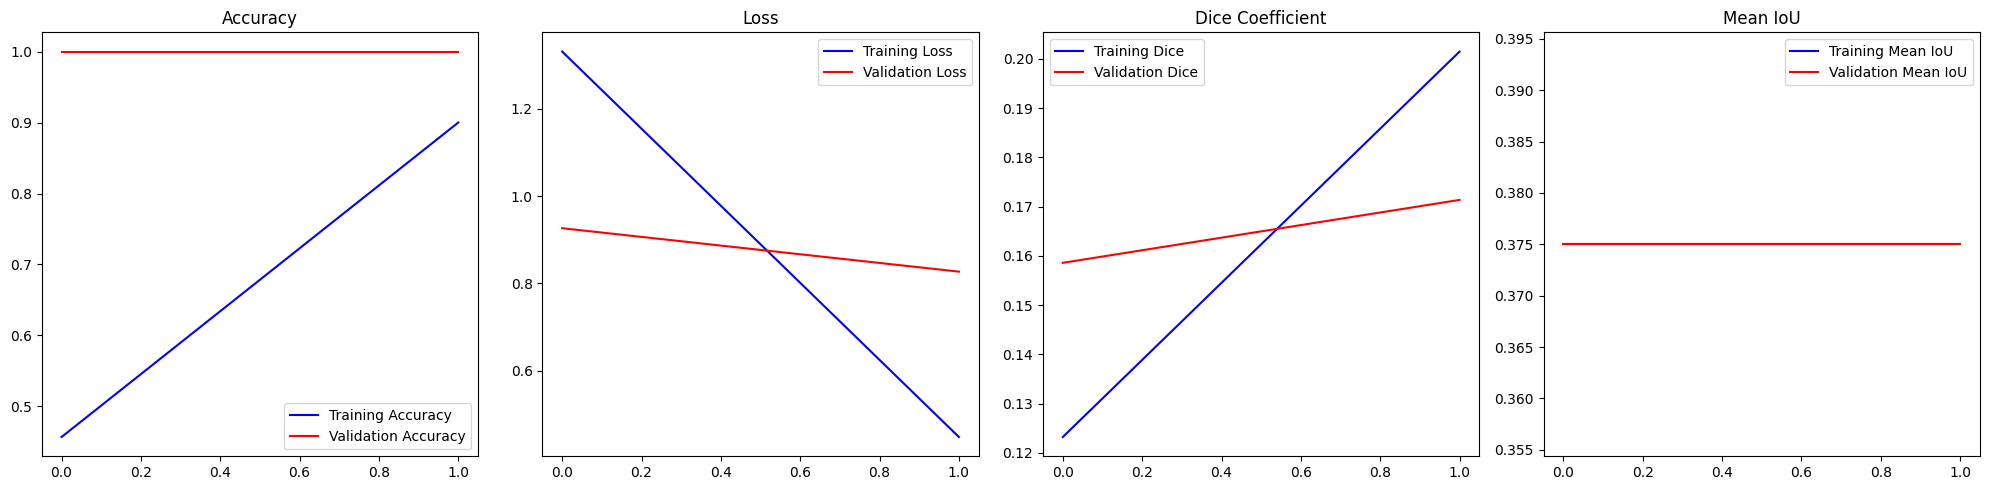

Final training accuracy:   0.9001
Final validation accuracy: 1.0000
Final training dice:       0.2015
Final validation dice:     0.1714


In [20]:
hist = history.history

acc = hist['accuracy']
val_acc = hist['val_accuracy']
loss = hist['loss']
val_loss = hist['val_loss']
train_dice = hist['dice_coef']
val_dice = hist['val_dice_coef']
train_iou = hist['mean_io_u']
val_iou = hist['val_mean_io_u']
epoch = range(len(acc))

f, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].plot(epoch, acc, 'b', label='Training Accuracy')
ax[0].plot(epoch, val_acc, 'r', label='Validation Accuracy')
ax[0].set_title('Accuracy'); ax[0].legend()

ax[1].plot(epoch, loss, 'b', label='Training Loss')
ax[1].plot(epoch, val_loss, 'r', label='Validation Loss')
ax[1].set_title('Loss'); ax[1].legend()

ax[2].plot(epoch, train_dice, 'b', label='Training Dice')
ax[2].plot(epoch, val_dice, 'r', label='Validation Dice')
ax[2].set_title('Dice Coefficient'); ax[2].legend()

ax[3].plot(epoch, train_iou, 'b', label='Training Mean IoU')
ax[3].plot(epoch, val_iou, 'r', label='Validation Mean IoU')
ax[3].set_title('Mean IoU'); ax[3].legend()

plt.tight_layout()
plt.show()

print(f"Final training accuracy:   {acc[-1]:.4f}")
print(f"Final validation accuracy: {val_acc[-1]:.4f}")
print(f"Final training dice:       {train_dice[-1]:.4f}")
print(f"Final validation dice:     {val_dice[-1]:.4f}")

In [21]:
MODEL_SAVE_PATH = 'brain_tumor_segmentation_hybrid_model.keras'
model.save(MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: brain_tumor_segmentation_hybrid_model.keras


In [22]:
custom_objects = {
    'BatchMatMul': BatchMatMul,
    'SliceChannel': SliceChannel,
    'dice_coef': dice_coef,
    'precision': precision,
    'sensitivity': sensitivity,
    'specificity': specificity,
    'dice_coef_necrotic': dice_coef_necrotic,
    'dice_coef_edema': dice_coef_edema,
    'dice_coef_enhancing': dice_coef_enhancing,
}

model = load_model(MODEL_SAVE_PATH, custom_objects=custom_objects)

print("Evaluate on test data")
results = model.evaluate(test_generator, batch_size=BATCH_SIZE, callbacks=callbacks, return_dict=True)
for k, v in results.items():
    print(f"{k:>22s}: {v:.4f}")

Evaluate on test data
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 1.0000 - dice_coef: 0.1773 - dice_coef_edema: 0.0000e+00 - dice_coef_enhancing: 0.0000e+00 - dice_coef_necrotic: 0.0000e+00 - loss: 0.7773 - mean_io_u: 0.3750 - precision: 1.0000 - sensitivity: 0.3939 - specificity: 1.0000
              accuracy: 1.0000
             dice_coef: 0.1773
       dice_coef_edema: 0.0000
   dice_coef_enhancing: 0.0000
    dice_coef_necrotic: 0.0000
                  loss: 0.7773
             mean_io_u: 0.3750
             precision: 1.0000
           sensitivity: 0.3939
           specificity: 1.0000


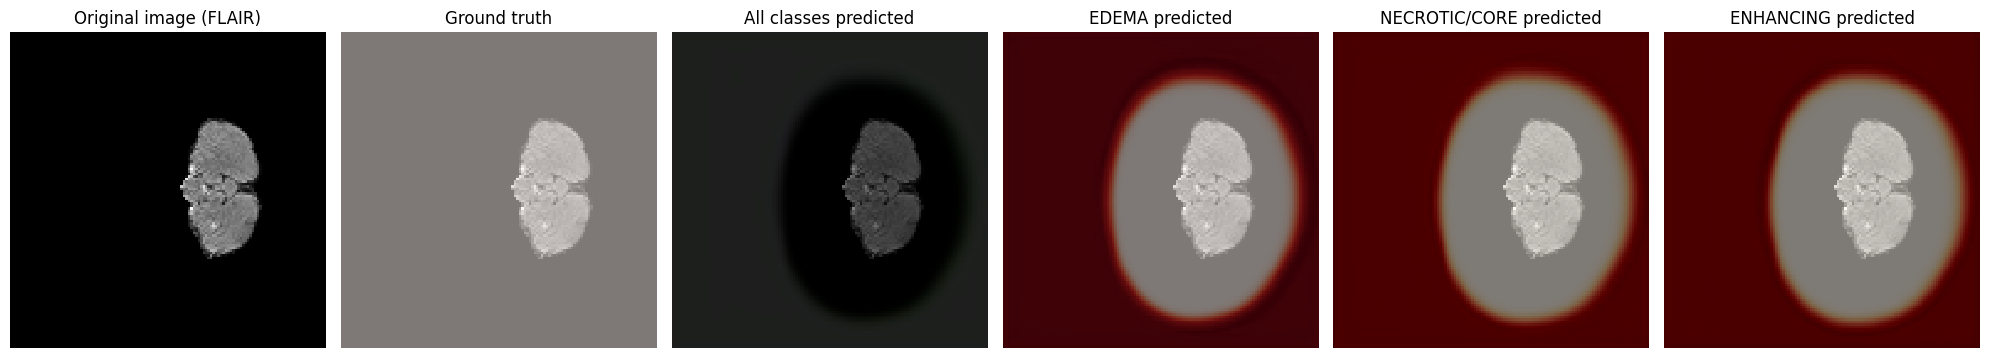

In [ ]:
for tid in test_ids:
    showPredictsById(case=tid, start_slice=0)  # or start_slice=5 if VOLUME_SLICES > 5

In [25]:
def showPredictsById(case, start_slice=0):
    path = TRAIN_DATASET_PATH

    gt_3d = np.zeros((240, 240, VOLUME_SLICES))
    flair_3d = np.zeros((240, 240, VOLUME_SLICES))

    # Count how many slices actually exist
    actual_slices = 0
    for j in range(VOLUME_SLICES):
        slice_idx = j + VOLUME_START_AT
        h5_file = os.path.join(path, f"volume_{case}_slice_{slice_idx}.h5")
        if os.path.exists(h5_file):
            actual_slices += 1
            with h5py.File(h5_file, 'r') as f:
                img = f['image'][:]
                msk = f['mask'][:]
                flair_3d[:, :, j] = img[:, :, 0]

                mask_slice = np.zeros((240, 240))
                mask_slice[msk[:, :, 0] == 1] = 1
                mask_slice[msk[:, :, 1] == 1] = 2
                mask_slice[msk[:, :, 2] == 1] = 3
                gt_3d[:, :, j] = mask_slice

    # If start_slice is out of bounds, use the middle slice
    if start_slice >= actual_slices:
        start_slice = actual_slices // 2
        print(f"Warning: start_slice adjusted to {start_slice} (middle of volume)")

    p = predictByPath(path, case)

    core = p[:, :, :, 1]
    edema = p[:, :, :, 2]
    enhancing = p[:, :, :, 3]

    f, axarr = plt.subplots(1, 6, figsize=(20, 6))
    resized_bg = cv2.resize(flair_3d[:, :, start_slice], (IMG_SIZE, IMG_SIZE))
    # ... rest of the function

In [ ]:
def get_actual_volume_slices(case):
    count = 0
    for j in range(200):  # Assume max 200 slices
        slice_idx = j + VOLUME_START_AT
        h5_file = os.path.join(TRAIN_DATASET_PATH, f"volume_{case}_slice_{slice_idx}.h5")
        if os.path.exists(h5_file):
            count += 1
        else:
            break
    return count

# Update VOLUME_SLICES based on actual data
VOLUME_SLICES = get_actual_volume_slices(test_ids[0])  # Use first test case as reference

In [ ]:
# Visualize different slices by iterating
for tid in test_ids:
    # Show middle slice
    showPredictsById(case=tid, start_slice=VOLUME_SLICES//2)

    # Or show multiple slices
    for slice_idx in range(0, VOLUME_SLICES, VOLUME_SLICES//3):
        showPredictsById(case=tid, start_slice=slice_idx)

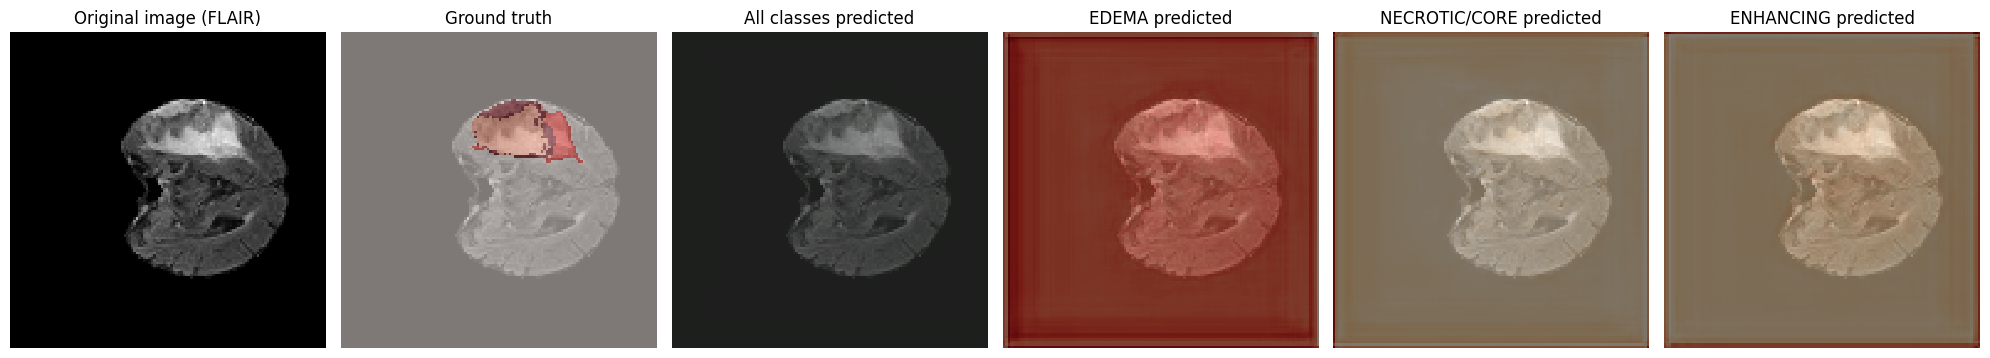

In [28]:
def predictByPath(case_path, case):
    '''Runs the model over every slice of one patient volume and returns the
    per-class probability maps, shape (VOLUME_SLICES, IMG_SIZE, IMG_SIZE, NUM_CLASSES).'''
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, IN_CHANNELS))

    for j in range(VOLUME_SLICES):
        slice_idx = j + VOLUME_START_AT
        h5_file = os.path.join(TRAIN_DATASET_PATH, f"volume_{case}_slice_{slice_idx}.h5")
        if os.path.exists(h5_file):
            with h5py.File(h5_file, 'r') as f:
                img = f['image'][:]
                X[j, :, :, 0] = cv2.resize(img[:, :, 0], (IMG_SIZE, IMG_SIZE))
                X[j, :, :, 1] = cv2.resize(img[:, :, 2], (IMG_SIZE, IMG_SIZE))

    max_val = np.max(X)
    if max_val > 0:
        X = X / max_val

    return model.predict(X, verbose=0)


def showPredictsById(case, start_slice=40):
    path = TRAIN_DATASET_PATH

    gt_3d = np.zeros((240, 240, VOLUME_SLICES))
    flair_3d = np.zeros((240, 240, VOLUME_SLICES))

    for j in range(VOLUME_SLICES):
        slice_idx = j + VOLUME_START_AT
        h5_file = os.path.join(path, f"volume_{case}_slice_{slice_idx}.h5")
        if os.path.exists(h5_file):
            with h5py.File(h5_file, 'r') as f:
                img = f['image'][:]
                msk = f['mask'][:]
                flair_3d[:, :, j] = img[:, :, 0]

                mask_slice = np.zeros((240, 240))
                mask_slice[msk[:, :, 0] == 1] = 1
                mask_slice[msk[:, :, 1] == 1] = 2
                mask_slice[msk[:, :, 2] == 1] = 3
                gt_3d[:, :, j] = mask_slice

    p = predictByPath(path, case)

    core = p[:, :, :, 1]
    edema = p[:, :, :, 2]
    enhancing = p[:, :, :, 3]

    f, axarr = plt.subplots(1, 6, figsize=(20, 6))
    resized_bg = cv2.resize(flair_3d[:, :, start_slice], (IMG_SIZE, IMG_SIZE))
    for i in range(6):
        axarr[i].imshow(resized_bg, cmap="gray", interpolation='none')
        axarr[i].axis('off')

    curr_gt = cv2.resize(gt_3d[:, :, start_slice], (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    axarr[0].set_title('Original image (FLAIR)')
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.5); axarr[1].set_title('Ground truth')
    axarr[2].imshow(p[start_slice, :, :, 1:4], cmap="Reds", interpolation='none', alpha=0.5); axarr[2].set_title('All classes predicted')
    axarr[3].imshow(edema[start_slice, :, :], cmap="Reds", interpolation='none', alpha=0.5); axarr[3].set_title(f'{SEGMENT_CLASSES[2]} predicted')
    axarr[4].imshow(core[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.5); axarr[4].set_title(f'{SEGMENT_CLASSES[1]} predicted')
    axarr[5].imshow(enhancing[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.5); axarr[5].set_title(f'{SEGMENT_CLASSES[3]} predicted')

    plt.tight_layout()
    plt.show()


for tid in test_ids:
    showPredictsById(case=tid)


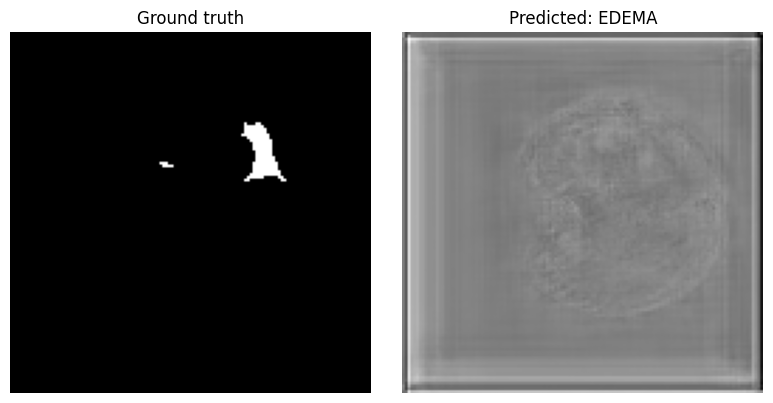

In [29]:
case = test_ids[0]
path = TRAIN_DATASET_PATH
p = predictByPath(path, case)

i = 40             # slice index
eval_class = 2      # 1: NECROTIC/CORE, 2: EDEMA, 3: ENHANCING

h5_file = os.path.join(path, f"volume_{case}_slice_{i+VOLUME_START_AT}.h5")
with h5py.File(h5_file, 'r') as f:
    msk = f['mask'][:]
    gt_class = msk[:, :, eval_class - 1].astype('float32')

resized_gt = cv2.resize(gt_class, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

f, axarr = plt.subplots(1, 2, figsize=(8, 4))
axarr[0].imshow(resized_gt, cmap="gray"); axarr[0].set_title('Ground truth')
axarr[1].imshow(p[i, :, :, eval_class], cmap="gray"); axarr[1].set_title(f'Predicted: {SEGMENT_CLASSES[eval_class]}')
for ax in axarr:
    ax.axis('off')
plt.tight_layout()
plt.show()
